In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
np.random.seed(42) # For reproducibility
# Generate 20 random points, sorted so plotting lines connects smoothly
x = np.sort(np.random.rand(20) * 10)
# Create a true underlying cubic relationship with some noise added
y_true = 0.5 * x**3 - 4 * x**2 + 2 * x + 10
y = y_true + np.random.normal(0, 15, len(x))

In [3]:
print("--- PART A: Linear vs Cubic Fit ---")


coeffs_linear = np.polyfit(x, y, 1)
y_pred_linear = np.polyval(coeffs_linear, x)
mse_linear = mean_squared_error(y, y_pred_linear)
r2_linear = r2_score(y, y_pred_linear)


coeffs_cubic = np.polyfit(x, y, 3)
y_pred_cubic = np.polyval(coeffs_cubic, x)
mse_cubic = mean_squared_error(y, y_pred_cubic)
r2_cubic = r2_score(y, y_pred_cubic)

print(f"Linear Fit -> MSE: {mse_linear:.2f}, R-Squared: {r2_linear:.4f}")
print(f"Cubic Fit  -> MSE: {mse_cubic:.2f}, R-Squared: {r2_cubic:.4f}")

if r2_cubic > r2_linear:
    print("Evaluation: The Cubic Polynomial is a better fit for this data.")
else:
    print("Evaluation: The Linear Least Squares is a better fit for this data.")




--- PART A: Linear vs Cubic Fit ---
Linear Fit -> MSE: 848.12, R-Squared: 0.3738
Cubic Fit  -> MSE: 173.94, R-Squared: 0.8716
Evaluation: The Cubic Polynomial is a better fit for this data.


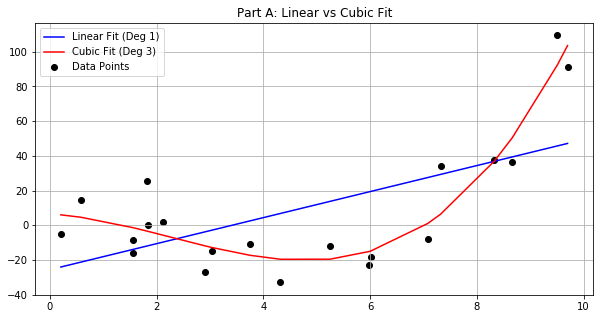

In [4]:
plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='black', label='Data Points')
plt.plot(x, y_pred_linear, color='blue', label='Linear Fit (Deg 1)')
plt.plot(x, y_pred_cubic, color='red', label='Cubic Fit (Deg 3)')
plt.title("Part A: Linear vs Cubic Fit")
plt.legend()
plt.grid(True)
plt.show()


--- PART B: Overfitting and Underfitting ---
Degree 1  -> MSE: 848.12   | R-Squared: 0.3738


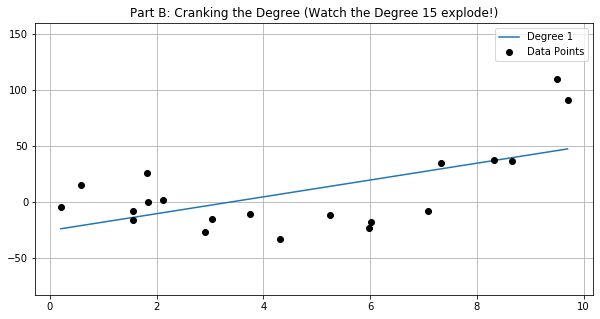

No handles with labels found to put in legend.


Degree 2  -> MSE: 237.06   | R-Squared: 0.8250


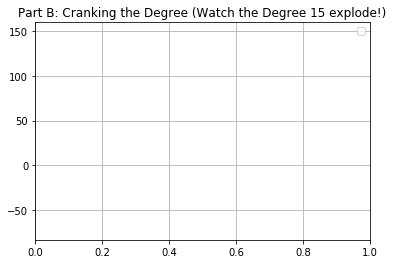

Degree 3  -> MSE: 173.94   | R-Squared: 0.8716


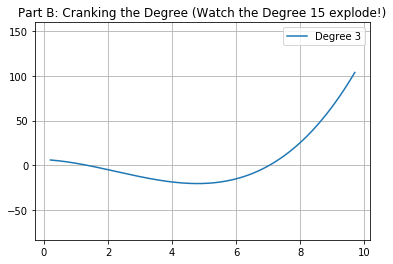

No handles with labels found to put in legend.


Degree 5  -> MSE: 163.19   | R-Squared: 0.8795


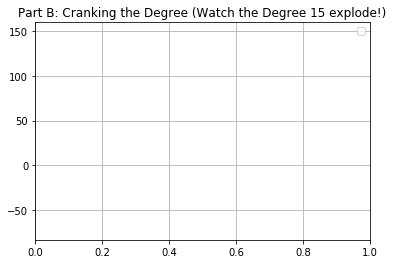

No handles with labels found to put in legend.


Degree 9  -> MSE: 147.06   | R-Squared: 0.8914


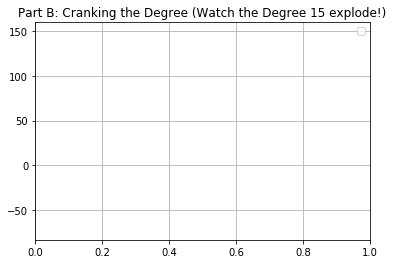

No handles with labels found to put in legend.


Degree 12 -> MSE: 78.66    | R-Squared: 0.9419


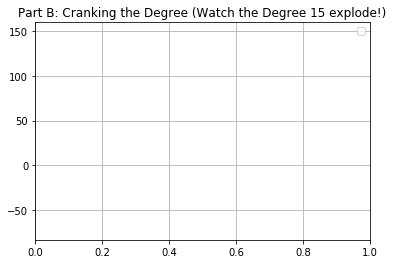

Degree 15 -> MSE: 20.47    | R-Squared: 0.9849


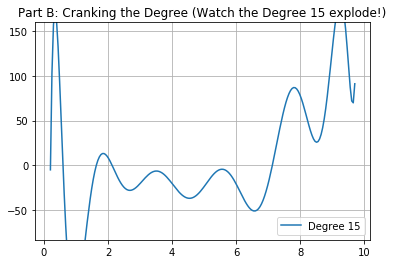

In [7]:
print("\n--- PART B: Overfitting and Underfitting ---")


degrees_to_test = [1, 2, 3, 5, 9, 12, 15]

plt.figure(figsize=(10, 5))
plt.scatter(x, y, color='black', label='Data Points', zorder=5)


x_dense = np.linspace(min(x), max(x), 200)

for deg in degrees_to_test:
    
    with np.errstate(all='ignore'): 
        coeffs = np.polyfit(x, y, deg)
        
    y_pred = np.polyval(coeffs, x)
    y_pred_dense = np.polyval(coeffs, x_dense)
    
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    print(f"Degree {deg:<2} -> MSE: {mse:<8.2f} | R-Squared: {r2:.4f}")
    
    
    if deg in [1, 3, 15]:
        plt.plot(x_dense, y_pred_dense, label=f'Degree {deg}')
    plt.ylim(min(y) - 50, max(y) + 50) # Limit y-axis so the overfit explosion doesn't ruin the scale
    plt.title("Part B: Cranking the Degree (Watch the Degree 15 explode!)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [8]:
print("\n--- PART C: Manual Vandermonde Matrix Fit ---")

degree = 3

V = np.vander(x, degree + 1, increasing=False)

V_transpose = V.T
weights = np.linalg.solve(V_transpose @ V, V_transpose @ y)

y_pred_vander = V @ weights

mse_vander = mean_squared_error(y, y_pred_vander)
r2_vander = r2_score(y, y_pred_vander)

print("Vandermonde Weights:", weights)
print("np.polyfit Weights: ", coeffs_cubic) # Notice they are identical!
print(f"Vandermonde Fit -> MSE: {mse_vander:.2f}, R-Squared: {r2_vander:.4f}")


--- PART C: Manual Vandermonde Matrix Fit ---
Vandermonde Weights: [ 0.41054337 -2.77192514 -1.72326472  6.47244016]
np.polyfit Weights:  [ 0.41054337 -2.77192514 -1.72326472  6.47244016]
Vandermonde Fit -> MSE: 173.94, R-Squared: 0.8716
